In [7]:
#Заргужаемые модули
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Настройки визуализации
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('pastel')

In [9]:
# Загружаем очищенные данные
df = pd.read_csv('D:/Projects/data-analytics-online-retail-/data/clean/OnlineRetail_clean.csv')

# Просмотр первых строк
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [10]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397924 entries, 0 to 397923
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397924 non-null  int64  
 1   StockCode    397924 non-null  object 
 2   Description  397924 non-null  object 
 3   Quantity     397924 non-null  int64  
 4   InvoiceDate  397924 non-null  object 
 5   UnitPrice    397924 non-null  float64
 6   CustomerID   397924 non-null  float64
 7   Country      397924 non-null  object 
 8   TotalPrice   397924 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 27.3+ MB


,InvoiceNo,Quantity,UnitPrice,CustomerID,TotalPrice
count,397924.000000,397924.000000,397924.000000,397924.000000,397924.000000
mean,560617.126645,13.021823,3.116174,15294.315171,22.394749
std,13106.167695,180.420210,22.096788,1713.169877,309.055588
min,536365.000000,1.000000,0.000000,12346.000000,0.000000
25%,549234.000000,2.000000,1.250000,13969.000000,4.680000
50%,561893.000000,6.000000,1.950000,15159.000000,11.800000
75%,572090.000000,12.000000,3.750000,16795.000000,19.800000
max,581587.000000,80995.000000,8142.750000,18287.000000,168469.600000


In [11]:
# Приобразуем дату и создадим дополнительные признаки
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour


In [15]:
# Общий обзор данных о продажах
print('Количество уникальных клиентов:', df['CustomerID'].nunique())
print('Количество уникальных товаров:', df['StockCode'].nunique())
print('Количество уникальных счетов:', df['InvoiceNo'].nunique())
print('Количество стран:', df['Country'].nunique())


Количество уникальных клиентов: 4339
Количество уникальных товаров: 3665
Количество уникальных счетов: 18536
Количество стран: 37


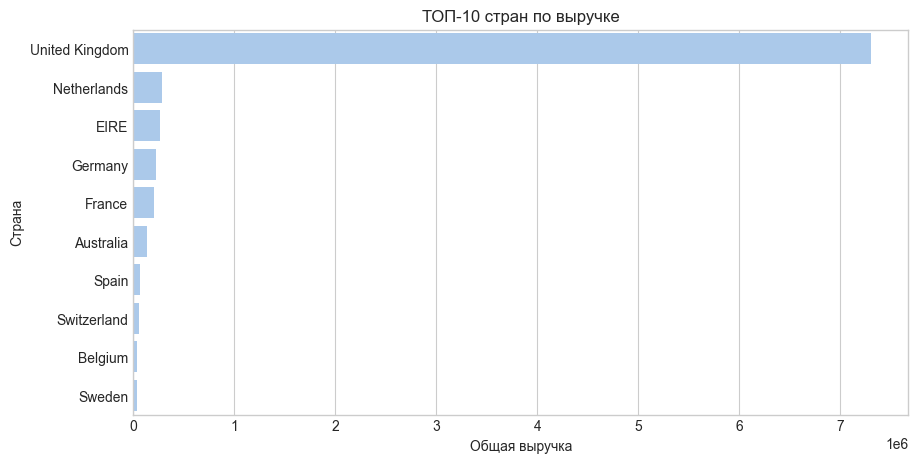

In [16]:
# ТОП-10 стран по выручке
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=country_sales.values, y=country_sales.index)
plt.title('ТОП-10 стран по выручке')
plt.xlabel('Общая выручка')
plt.ylabel('Страна')
plt.show()


💬 Вывод:
Основная часть выручки приходится на Великобританию (UK), на другие страны — небольшая доля.

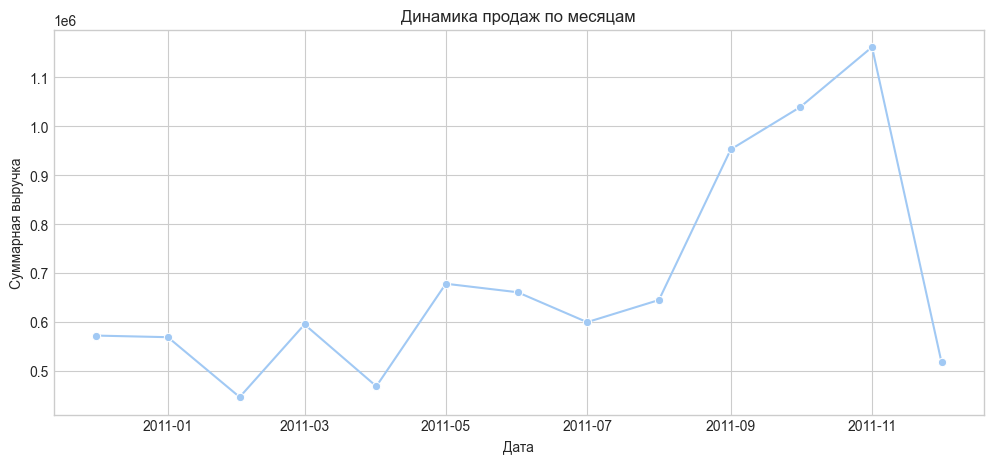

In [17]:
# Распределение продаж по месяцам
monthly_sales = df.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(DAY=1))

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='Date', y='TotalPrice', marker='o')
plt.title('Динамика продаж по месяцам')
plt.xlabel('Дата')
plt.ylabel('Суммарная выручка')
plt.show()

💬 Комментарий:
Видны сезонные пики — ноябрь и декабрь (праздничные продажи).

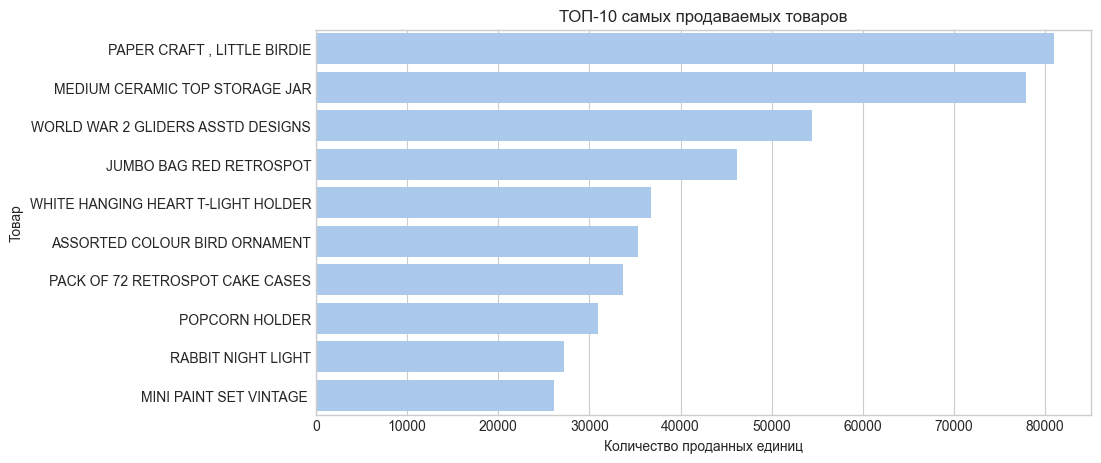

In [18]:
#  ТОП-10 популярных товаров
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('ТОП-10 самых продаваемых товаров')
plt.xlabel('Количество проданных единиц')
plt.ylabel('Товар')
plt.show()

💬 Вывод:
Лидируют мелкие сувенирные и праздничные товары (candles, bags, decorative items).

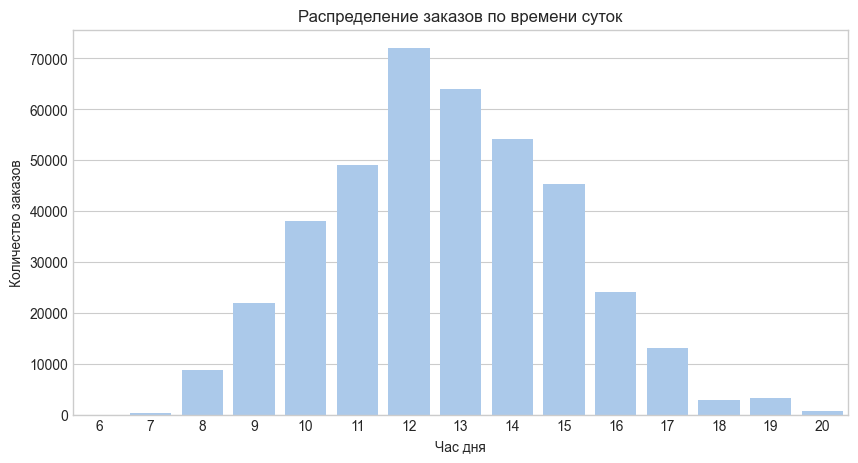

In [19]:
# Распределение заказов по времени суток
hourly_sales = df.groupby('Hour')['InvoiceNo'].count()

plt.figure(figsize=(10,5))
sns.barplot(x=hourly_sales.index, y=hourly_sales.values)
plt.title('Распределение заказов по времени суток')
plt.xlabel('Час дня')
plt.ylabel('Количество заказов')
plt.show()

💬 Комментарий:
Пик покупок — в рабочее время (10–16 часов), спад ночью.

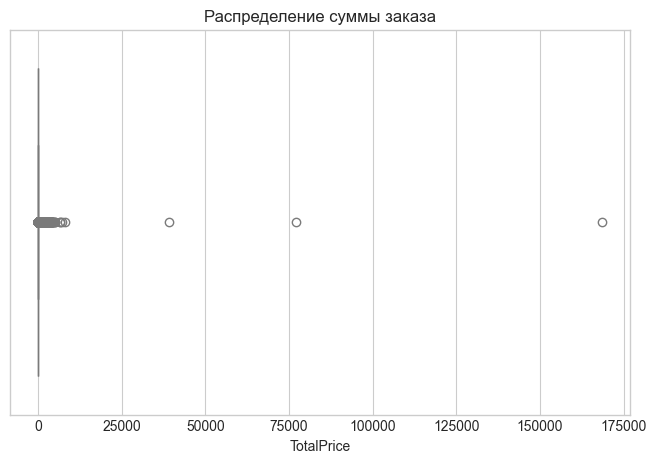

count    397924.000000
mean         22.394749
std         309.055588
min           0.000000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64

In [20]:
# Распределение по сумме заказа
plt.figure(figsize=(8,5))
sns.boxplot(x=df['TotalPrice'])
plt.title('Распределение суммы заказа')
plt.show()

df['TotalPrice'].describe()

💬 Вывод:
Есть выбросы — редкие крупные заказы, большинство покупок на сумму до 100.

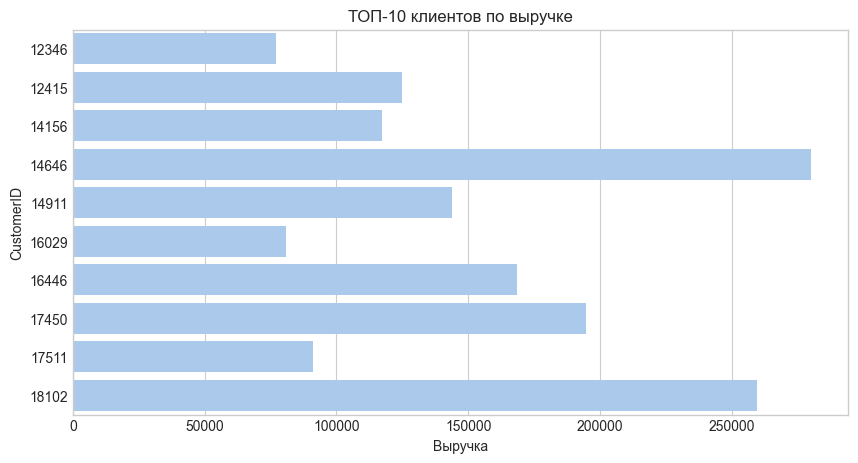

In [63]:
# Топ-10 клиентов по выручке
top_customers = df.groupby('CustomerID').agg({'TotalPrice': 'sum'}).sort_values('TotalPrice', ascending=False).head(10).reset_index()
top_customers['CustomerID'] = top_customers['CustomerID'].astype(int)

plt.figure(figsize=(10, 5))
sns.barplot(x='TotalPrice', y='CustomerID', data=top_customers, orient='h')
plt.title('ТОП-10 клиентов по выручке')
plt.xlabel('Выручка')
plt.ylabel('CustomerID')
plt.show()

💬 Комментарий:
Небольшая группа клиентов генерирует большую часть выручки (эффект 80/20).